# Stereovision

![Suzanne](main.png)

Stereovision is a discipline that deals with the reconstruction of 3D information from images. For the reconstruction of a point, several images of this point are needed. These images must be taken from different points of view. The key step of the reconstruction, which is often problematic, is to identify the images of the point to be reconstructed in each view.

## Epipolar Geometry

Epipolar geometry involves two cameras. The epipolar geometry describes the geometric properties between two views of the same scene and depends only on the intrinsic parameters of the cameras and their relative positions. It provides, in particular, the epipolar constraint, which will be very useful to produce the matches between views.

## The Fondamental Matrix

![Epipolar Geometry - Sanyam Kapoor](epipolar.png)

Let us imagine that we have two images, right and left, of the world space. Let's take a point $\vec{x}$ in the right image space. The point $\vec{X}$ of the world space, of which $\vec{x}$ is the image, can be anywhere on the line passing through $\vec{x}$ and the optical center of the right camera. We will call this line the back-projected ray of $\vec{x}$. Let us note $\vec{x}'$ the image of $\vec{X}$ in the left image space. The locus of $\vec{x}'$ is therefore the image line of the back-projected ray of $\vec{x}$. This line is called the epipolar line and is denoted $\vec{l}'$. The epipolar line passes through the epipole $\vec{e}'$, image of the optical center of the right camera.

In 2D projective geometry, a line with equation $ax+by+c = 0$ is represented by a vector with three components $(a, b, c)^T$ defined to within one factor. Thus, we have the following relationship:

>The point $\vec{x}$ belongs to the line $\vec{l}$ if and only if $x^T\vec{l} = 0$.

Moreover, in 2D projective geometry, the following remarkable relations are valid:

- The intersection of two lines $l$ and $l'$ is given by $x = l \times l'$,
- The line passing through two points $x$ and $x'$ is given by $l = x \times x'$.

Note that the vector product can be written as a product of matrix $x \times y = [x]_\times y$ where

$$[x]_\times = \begin{pmatrix} 0 & −x3 & x2 \\ x3 & 0 & −x1 \\ −x2 & x1 & 0 \end{pmatrix}$$

To find the equation of the epipolar line in the left image space, we just need to find the coordinates of two points of this line. The first is the image $P'\vec{C}$ of the optical center $\vec{C}$ of the right camera where $P'$ is the projection matrix of the left camera. The second is $P'P^{+}\vec{x}$ where $P^{+}$ is the pseudo inverse of the projection matrix $P$ of the right camera. The epipolar line thus has the equation $l' = [P'\vec{C}]_\times{}P'P^{+}\vec{x} = F\vec{x}$ with $F = [P'\vec{C}]_\times{}P'P^{+}$. $F$ is called fundamental matrix.

Since the epipolar line $\vec{l}' = F\vec{x}$ is the locus of $\vec{x}'$, $\vec{x}'$ therefore belongs to $\vec{l}'$ which leads to the epipolar constraint :

>**The fundamental matrix is such that for any pair of points corresponding $\vec{x} \leftrightarrow \vec{x}'$ in the two images, we have $\vec{x}'^{T}F\vec{x} = 0$.**

## Computation of the fundamental matrix

The fundamental matrix $F$ has seven degrees of freedom. It has nine components but these are defined to within one scale factor, which removes one degree of freedom. Moreover, the matrix $F$ is a singular matrix ($det(F) = 0$) which gives us seven degrees of freedom. So we need at least seven correspondences to compute $F$. The equation $x'^{T}_iFx_i = 0$ and the seven correspondences allow us to write a system of equations of the form $Af = 0$, where $f$ is the vector which contains the components of the matrix $F$. Let us assume that $A$ is a 7×9 matrix of rank 7. The general solution of $Af = 0$ can be written $\alpha f_1 + (1-\alpha) f_2$ where $f_1$ and $f_2$ are two particular independent solutions of $Af = 0$. We then use the singularity constraint $det(\alpha F_1 + (1 - \alpha)F_2) = 0$ to determine $\alpha$. Since the singularity constraint gives rise to a third degree equation, we may have one or three solutions for $F$.

## OpenCV

In practice you will use the OpenCV library. In python, you have access to its functions through the `cv2` module.

You can find help with the calibration and reconstruction functions on the site https://docs.opencv.org/4.0.0/d9/d0c/group__calib3d.html

## Goal

In the zip of the statement you will find two sequences of images taken by two cameras during the scanning of an object by a laser plane.

![Laser](scanRight/scan0010.png)

You will also find shots of a checkerboard in different positions that will help you calibrate your cameras.

![Damier](chessboards/c2Right.png)

The goal is to reconstruct the scanned object in 3D.

# Calibration des caméras:

Pour calibrer les caméras, on va utiliser l'échiquier. On ne va pas utiliser de mm mais les carrés de la board comme unité de mesure. Il faut donc définir un carré (unité), et la taille de la board (8 par 8 dans ce cas)

On importe ensuite l'image avec OpenCV
(Traitement sur des images en échelle de gris moins lourd à effectuer, et suffisant dans le cadre d'une calibration de caméra --> conversion de l'image en échelles de gris.)

Utilisation du filtre HSV pour faire ressortir davantage le chessboard.

Après avoir tout essayé (filtre hsv, mise en noir et blanc... la détection de bords qui fonctionne le mieux est en fait sur l'image sans préprocess...





# Doc 

## cv2.findChessboardCorners()
Find the chessboard corners in a chessboard image using cv2.findChessboardCorners(). It returns two output parameters ret and corners. The ret is True if the chessboard corners are detected in the image.

## cv2.cornerSubPix()
https://theailearner.com/tag/cv2-cornersubpix/

## Camera calibration 
https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html

types of distortion caused by cameras

how to find the intrinsic and extrinsic properties of a camera

how to undistort images based off these properties

Intrinsic parameters are specific to a camera. They include information like focal length (fx,fy) and optical centers (cx,cy). The camera matrix is unique to a specific camera, so once calculated, it can be reused on other images taken by the same camera. It is expressed as a 3x3 matrix

Matrices de calibration obtenues grâce à ça : mtx (décrivent comment les coordonnées 3D dans le monde sont projetées sur le plan image de chaque caméra)

## Rodrigues
Après calibration, on obtient des vecteurs de rotation de la caméra. Pour projeter les points 2D en 3D, il faut mettre ces vecteurs de rotation ensemble pour obtenir une matrice de rotation.

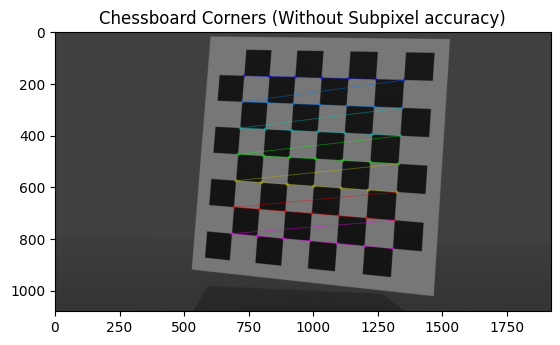

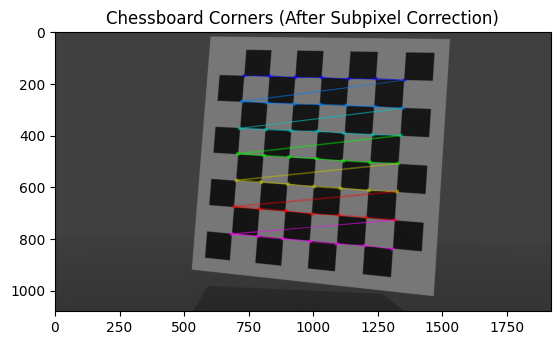

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ChessRight4 = cv2.imread('chessboards/c4Right.png')
ChessLeft4 = cv2.imread('chessboards/c4Left.png')

ret, corners = cv2.findChessboardCorners(ChessRight4, (7, 7), flags=cv2.CALIB_USE_INTRINSIC_GUESS)

# Si les coins de l'échiquier sont détectés
if ret == True:
    # avant subpixel
    img = cv2.drawChessboardCorners(ChessRight4, (7, 7), corners, ret)
    plt.imshow(img, cmap='gray')
    plt.title("Chessboard Corners (Without Subpixel accuracy)")
    plt.show()

    #  critères arrêt de la correction subpixel : 30 itérations ou précision de 0.001
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

    # Applique la correction subpixel aux coins détectés
    corners = cv2.cornerSubPix(cv2.cvtColor(ChessRight4, cv2.COLOR_BGR2GRAY), corners, (5, 5), (-1, -1), criteria)

    # Affiche et dessine les coins détectés après correction subpixel
    img = cv2.drawChessboardCorners(ChessRight4, (7, 7), corners, ret)
    plt.imshow(img, cmap='gray')
    plt.title("Chessboard Corners (After Subpixel Correction)")
    plt.show()
    
    
    
    # coordonnées réelles : comment les connaître?? on considère que la board est sur un plan (z = 0)?
    #ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
    #obj point : repère du chessboard

    

    
    
    





Rotation Matrix R1:
 [[ 0.9805611  -0.07186189 -0.18258096]
 [ 0.08295999  0.99509513  0.05388256]
 [ 0.17781332 -0.06798206  0.98171323]]
Rotation Matrix R2:
 [[ 0.97458726 -0.07316851  0.21172163]
 [ 0.06317078  0.99656152  0.05361514]
 [-0.21491657 -0.03887801  0.97585827]]
Projection Matrix P1:
 [[ 0.9805611  -0.07186189 -0.18258096 -2.30220487]
 [ 0.08295999  0.99509513  0.05388256 -3.6663503 ]
 [ 0.17781332 -0.06798206  0.98171323 19.80995819]]
Projection Matrix P2:
 [[ 0.97458726 -0.07316851  0.21172163 -2.26075258]
 [ 0.06317078  0.99656152  0.05361514 -3.61761906]
 [-0.21491657 -0.03887801  0.97585827 20.69524425]]


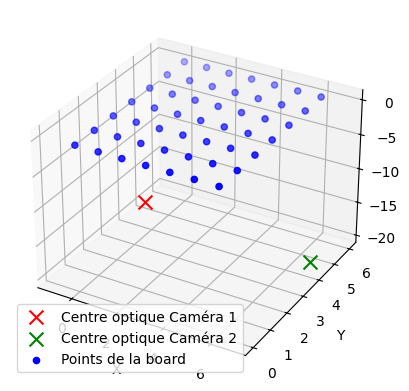

Fundamental Matrix F:
 [[ 1.01595874e-09  7.66769270e-07 -5.01844551e-04]
 [ 8.58496630e-07 -5.47521516e-09 -9.35094157e-03]
 [-5.50636605e-04  7.81168669e-03  1.00000000e+00]]
First 5 Triangulated Points (X, Y, Z):
 [[-4.39958647e-04  1.55356829e-03 -1.46089087e-03]
 [ 9.99983311e-01  5.56247367e-04 -4.20806056e-04]
 [ 1.99877119e+00  1.84384710e-03 -1.31283875e-03]
 [ 3.00002837e+00  4.10735556e-05  1.01475795e-04]
 [ 4.00057840e+00 -5.14686399e-04  4.23953170e-04]]
Total number of triangulated points: 147


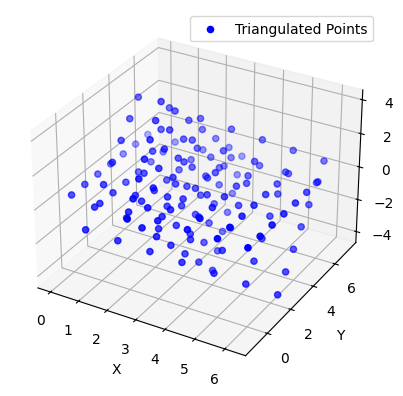

In [2]:
import cv2 
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob

def findPoints(pathToCalibrate):
    # Préparez les points objets du monde réel
    objp = np.zeros((7*7, 3), np.float32)
    objp[:, :2] = np.mgrid[0:7, 0:7].T.reshape(-1, 2)
    
    
    # Tableaux pour stocker les points objets et les points image de toutes les images
    objpoints = []  # Point 3D dans l'espace du monde réel
    imgpoints = []  # Point 2D dans le plan image
    

    images = glob.glob(pathToCalibrate)
    images.sort() #attention : glob ne sort pas les images dans le bon ordre
    
    
    for image in images:
        img = cv.imread(image)
        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        # Trouvez les coins de l'échiquier
        ret, corners = cv.findChessboardCorners(gray, (7, 7), None)

        if ret:
            objpoints.append(objp)
            criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)
            corners2 = cv.cornerSubPix(gray, corners, (5, 5), (-1, -1), criteria)
            
            
            imgpoints.append(corners2)
            '''for corner in corners2:
                
                img = cv2.circle(img, (int(corner[0][0]), int(corner[0][1])), 8, (255, 0, 0), -1)
            plt.imshow(img, cmap='gray')
                 
            plt.title("corners")
            plt.show()'''
    return objpoints, imgpoints, gray

def calibrateCamera(pathToCalibrate):
    objpoints, imgpoints, gray = findPoints(pathToCalibrate)
    
    ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
    #print('mtx:', mtx, 'dist:', dist, 'rvecs:', rvecs, 'tvecs:', tvecs)
    
    return mtx, dist, rvecs, tvecs



    
    
def findProjection(pathToCalibrate1, pathToCalibrate2):
    # Calibrer les caméras
    mtx1, dist1, rvecs1, tvecs1 = calibrateCamera(pathToCalibrate1)  # P_int = mtx
    mtx2, dist2, rvecs2, tvecs2 = calibrateCamera(pathToCalibrate2)

    # Calcul des matrices de rotation
    R1, _ = cv.Rodrigues(rvecs1[2])  # Matrice de rotation de la caméra 1
    R2, _ = cv.Rodrigues(rvecs2[2])  # Matrice de rotation de la caméra 2
    print("Rotation Matrix R1:\n", R1)
    print("Rotation Matrix R2:\n", R2)

    # Construction des matrices de projection 3x4
    P1 = np.concatenate((R1, tvecs1[2]), axis=1)  # P1 = P_ext
    P2 = np.concatenate((R2, tvecs2[2]), axis=1)

    # Affichage des matrices de projection
    print("Projection Matrix P1:\n", P1)
    print("Projection Matrix P2:\n", P2)

    return P1, P2, R1, R2


def plotCameras(pathToPlot1, pathToPlot2):
    _, _, R1, R2 = findProjection(pathToPlot1, pathToPlot2)

    #translation vectors
    _, _, _, tvecs1 = calibrateCamera(pathToPlot1)
    _, _, _, tvecs2 = calibrateCamera(pathToPlot2)

    # Calculate the optical centers using the rotation and translation matrices
    # Optical center of Camera 1 (C1)
    C1 = -np.dot(np.linalg.inv(R1), tvecs1[2])

    # Optical center of Camera 2 (C2)
    C2 = -np.dot(np.linalg.inv(R2), tvecs2[2])
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Afficher les centres optiques des caméras
    ax.scatter(C1[0], C1[1], C1[2], c='r', marker='x', s=100, label='Centre optique Caméra 1')
    ax.scatter(C2[0], C2[1], C2[2], c='g', marker='x', s=100, label='Centre optique Caméra 2')

    
    objpoints, _, _ = findPoints(pathToPlot1)
    if objpoints:
        objpoints = np.array(objpoints)[0]
        ax.scatter(objpoints[:, 0], objpoints[:, 1], objpoints[:, 2], c='b', marker='o', label='Points de la board')

    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.legend()

    
    plt.show()

    
plotCameras("chessboards/*Left.png", "chessboards/*Right.png")



def triangulate_with_F(imgPoints1, imgPoints2, P1, P2):
    # Calcul de la matrice fondamentale
    F, mask = cv.findFundamentalMat(imgPoints1, imgPoints2, cv.FM_RANSAC)

    if F is None:
        raise ValueError("Fundamental Matrix not found")

    # Afficher la matrice fondamentale
    print("Fundamental Matrix F:\n", F)

    # Triangulation des points
    points_homogeneous = cv2.triangulatePoints(P1, P2, imgPoints1.T, imgPoints2.T)

    # Normalisation des points
    points_normalized = points_homogeneous / points_homogeneous[3]

    # Afficher un échantillon des points triangulés
    print("First 5 Triangulated Points (X, Y, Z):\n", points_normalized[:3, :5].T)

    # Afficher le nombre total de points triangulés
    print(f"Total number of triangulated points: {points_normalized.shape[1]}")

    return points_normalized[:3]  # Retourner les coordonnées X, Y, Z



# Get camera matrices P1 and P2
#P1, P2, _, _ = findProjection("chessboards/*Left.png", "chessboards/*Right.png")

# Get image points
_, imgpoints1, _ = findPoints("chessboards/*Left.png")
_, imgpoints2, _ = findPoints("chessboards/*Right.png")


imgpoints1 = np.array(imgpoints1).reshape(-1, 2)
imgpoints2 = np.array(imgpoints2).reshape(-1, 2)

P1 = np.array([[ 2.06233961e+03,6.06139910e+02,-8.38594979e+02,1.42159891e+04],[ 4.65149825e+02,1.42986929e+03,1.55956302e+03,5.86342541e+03],[ 7.79396834e-01,-4.01196898e-01,4.81229284e-01,2.19305317e+01]])
P2 = np.array([[ 2.30432609e+03,8.86626799e+01,-1.32478576e+02,1.50658018e+04],[ 2.70155890e+02,1.33263788e+03,1.68984476e+03,6.72241077e+03],[ 4.76778328e-01,-5.55835540e-01,6.80976710e-01,2.32758156e+01]])
# Perform triangulation
#triangulated_points = triangulate_points(P1, P2, imgpoints1.T, imgpoints2.T)

# Perform triangulation
triangulated_points = triangulate_with_F(imgpoints1, imgpoints2, P1, P2)

# Plot the 3D points
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y, Z coordinates
X = triangulated_points[0]
Y = triangulated_points[1]
Z = triangulated_points[2]

# Plot the 3D points
ax.scatter(X, Y, Z, c='b', marker='o', label='Triangulated Points')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.legend()
plt.show()



Matrice de rotation (rotation matrix):

Formulaire : rmatLeft, rmatRight
Fonction : Ces matrices représentent la rotation d'un vecteur dans l'espace. Elles sont générées à partir des vecteurs de rotation rvecsL[2] et rvecsR[2], qui sont souvent obtenus à partir d'une technique de résolution de pose (comme la méthode de Rodrigues).
Matrice complète [R|t] (full [R|t] matrix):

Formulaire : rotMatRight, rotMatLeft
Fonction : Cette matrice étend la matrice de rotation avec le vecteur de translation (tvecsR[0] et tvecsL[0]). Elle combine la rotation et la translation pour représenter la transformation rigide complète d'une caméra par rapport à une autre. C'est essentiel dans les systèmes stéréo pour décrire la pose relative entre les deux caméras.
Matrice de caméra (camera matrix) :

Formulaire : camLeft, camRight
Fonction : Ces matrices intègrent la matrice intrinsèque de la caméra (représentée par cameraMatrixL et cameraMatrixR) avec la matrice complète [R|t]. La matrice intrinsèque décrit les paramètres internes de la caméra, tels que la distance focale et le point principal. La multiplication de la matrice intrinsèque par la matrice complète [R|t] donne la matrice de caméra, qui est utilisée pour transformer les coordonnées 3D du monde en coordonnées 2D de l'image.

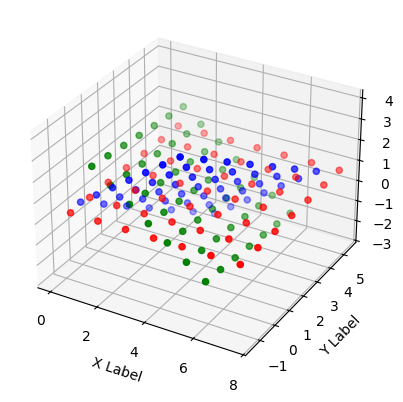

36
36
36


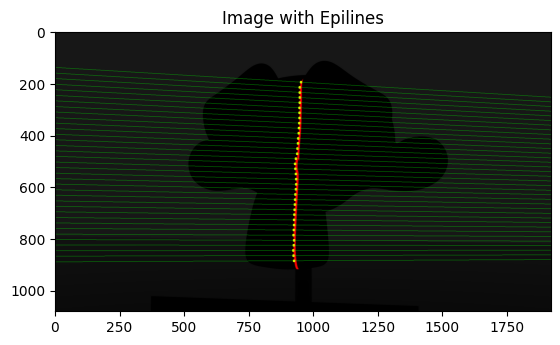

34
34
34


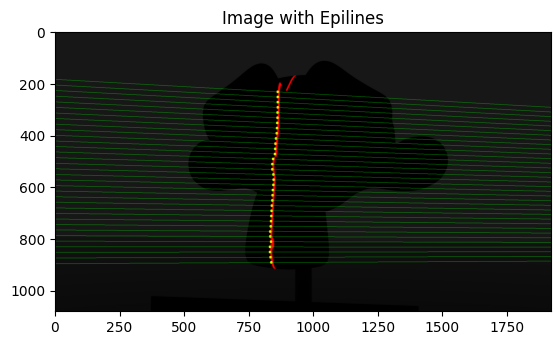

37
37
37


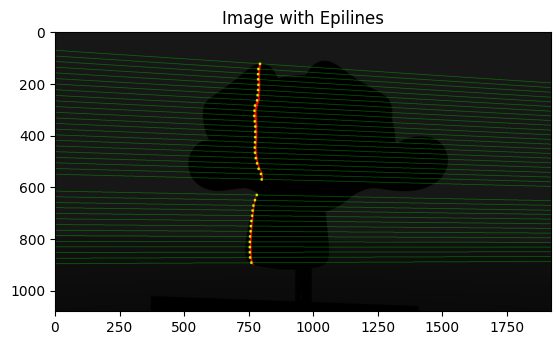

22
22
22


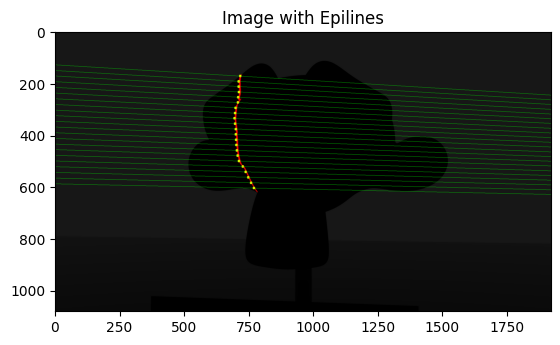

18
18
18


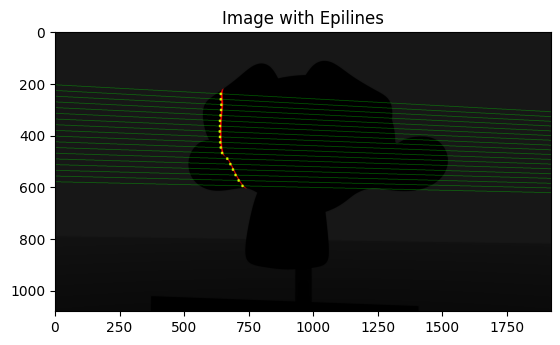

12
12
12


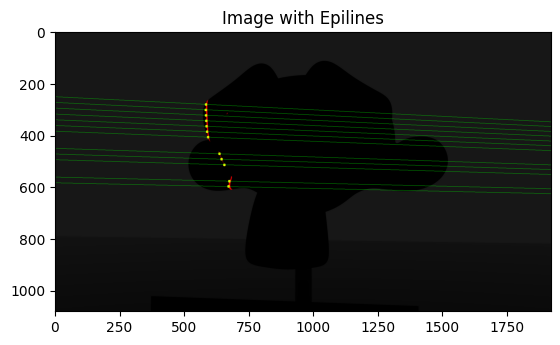

5
5
5


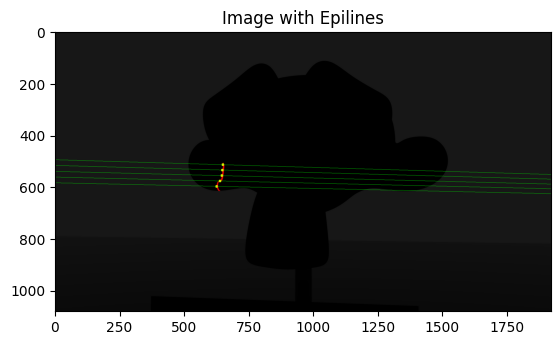

22
22
22


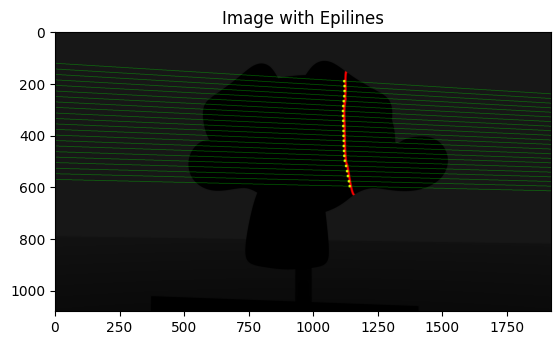

19
19
19


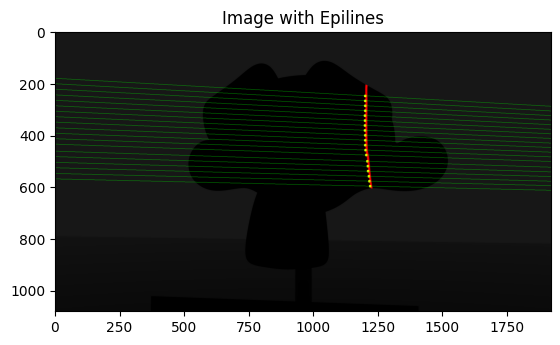

10
10
10


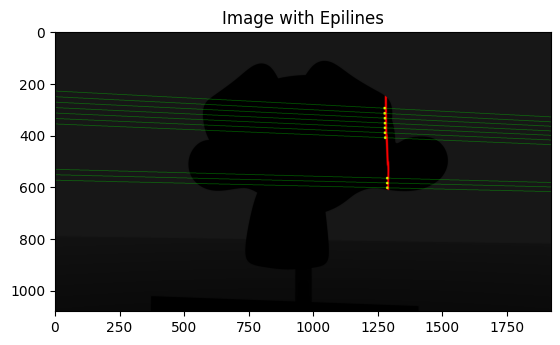

6
6
6


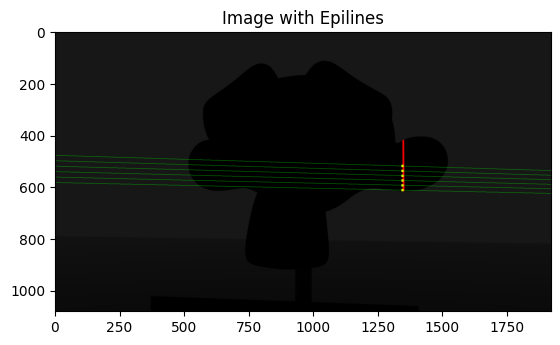

8
8
8


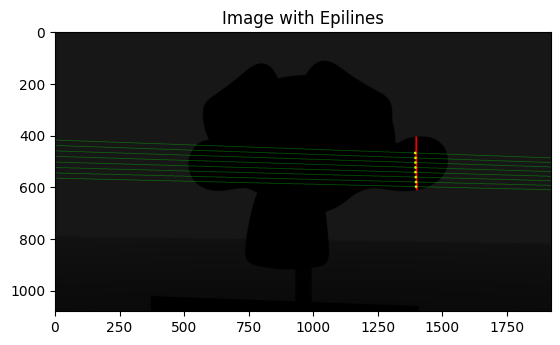

9
9
9


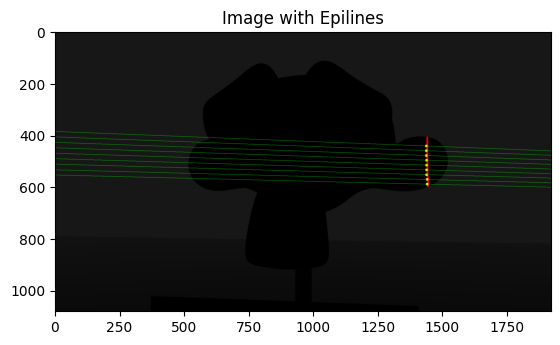

7
7
7


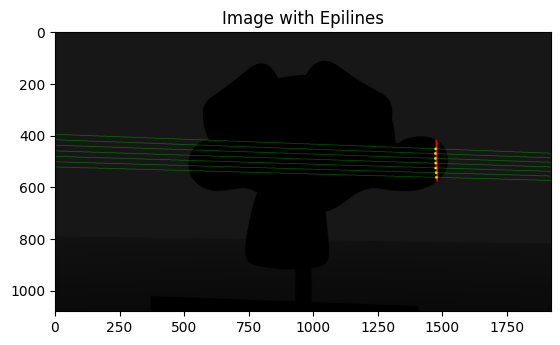

5
5
5


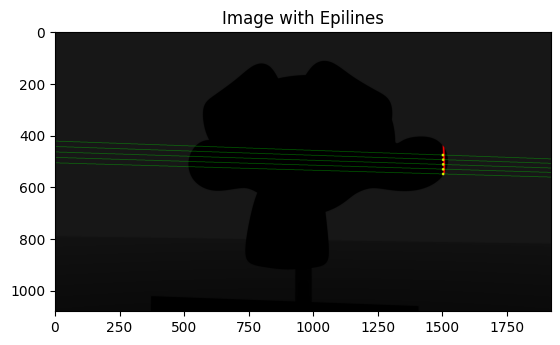

8
8
8


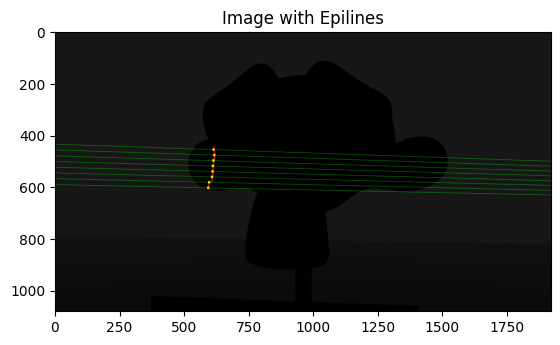

8
8
8


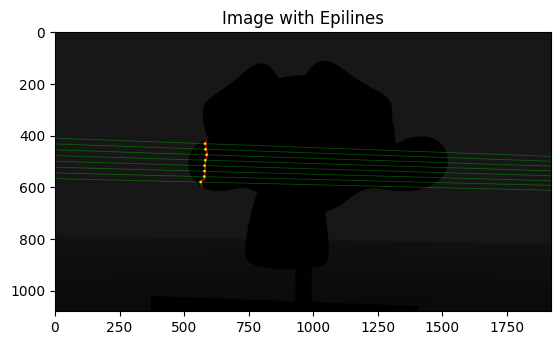

7
7
7


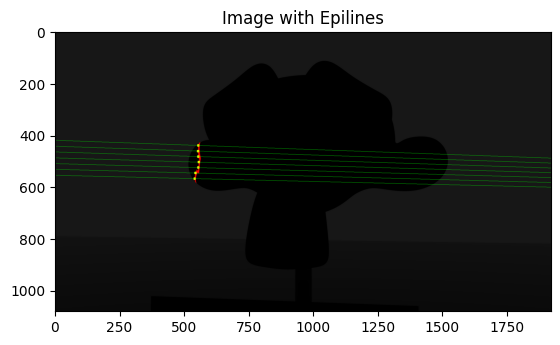

5
5
5


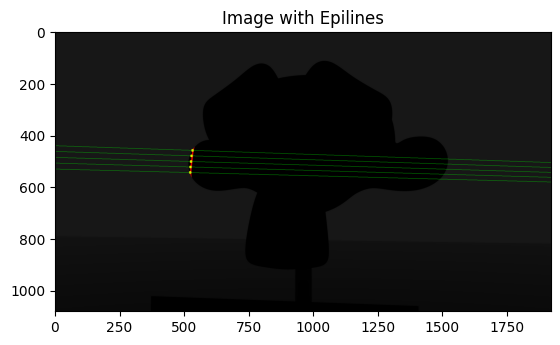

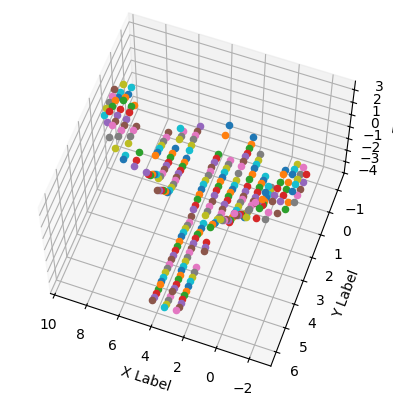

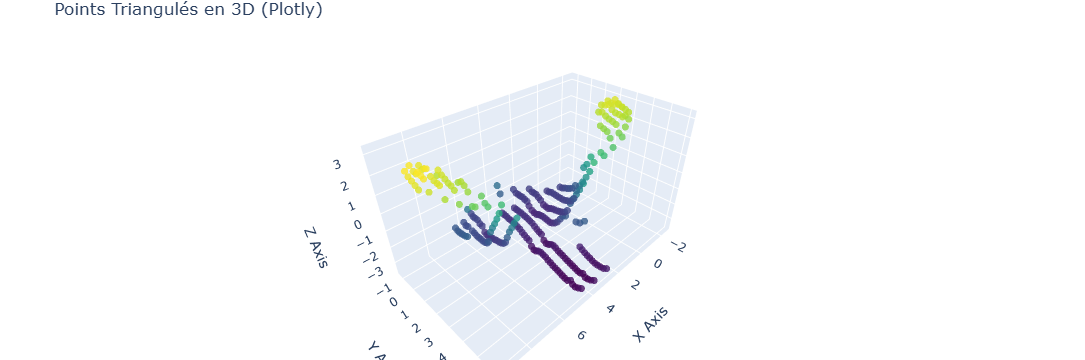

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob


def findPoints(pathToCalibrate):
    # prepare object points in the real world
    objp = np.zeros((7*7, 3), np.float32)
    objp[:, :2] = np.mgrid[0:7, 0:7].T.reshape(-1, 2)

    # Arrays to store object points and image points from all the images.
    objpoints = []  # 3D points in the real-world space
    imgpoints = []  # 2D points in the image plane.

    images = glob.glob(pathToCalibrate)
    images.sort()

    for image in images:
        img = cv2.imread(image)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        ret, corners = cv2.findChessboardCorners(gray, (7, 7), None)

        # If found, add object points and image points (after refining them)
        if ret:
            objpoints.append(objp)
            criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
            corners2 = cv2.cornerSubPix(gray, corners, (5, 5), (-1, -1), criteria)
            imgpoints.append(corners2)

            imgToPrint = cv2.drawChessboardCorners(img, (7, 7), corners2, ret)
            '''plt.imshow(imgToPrint, cmap='gray')
            plt.title("Chessboard Corners (After Subpixel Correction) " + pathToCalibrate)
            plt.show()'''

    return objpoints, imgpoints, gray


objPoints, imgPointsRight, gray = findPoints("chessboards/*Right.png")
_, imgPointsLeft, _ = findPoints("chessboards/*Left.png")
#print(gray.shape[::-1])
#print(gray.dtype)

def cameraCalibrate(objpoints, imgpoints, gray):
    
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, (1920,1080), None, None)
    #différentes mtrcies : voir texte
    rotationMatrixtemp, _ = cv2.Rodrigues(rvecs[2])
    
    rotationMatrix = np.concatenate((rotationMatrixtemp,tvecs[0]), axis=1)
    #matrice de caméra:
    
    cameraMatrix = mtx @ rotationMatrix
    
    cameraCenter = -np.dot(np.linalg.inv(rotationMatrixtemp), tvecs[0])
    cameraCenter = np.vstack([cameraCenter, [1]])
    
    # Compute the projection matrix (P)
    P = np.dot(mtx, np.hstack((rotationMatrixtemp, tvecs[0].reshape(-1, 1))))
    
    return ret, mtx, dist, rvecs, tvecs, cameraCenter, P

retL, mtxL, distL, rvecsL, tvecsL, cameraCenterL, PL = cameraCalibrate(objPoints, imgPointsLeft, gray.shape[::-1])
retR, mtxR, distR, rvecsR, tvecsR, cameraCenterR, PR = cameraCalibrate(objPoints, imgPointsRight, gray.shape[::-1])
      
_, _, _, _, _, R, T, E, FundementalMatrix = cv2.stereoCalibrate(objPoints, imgPointsLeft, imgPointsRight, mtxL, distL, mtxR, distR, gray.shape[::-1],(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))

    

                     
def triangulateChessboardCorners(P_l, P_r, left_corners, right_corners):
    # Perform triangulation for each pair of corresponding corners
    triangulated_points = []

    for i in range(len(left_corners)):
        left_point = left_corners[i]
        right_point = right_corners[i]
        

        # Perform triangulation for the pair of points
        points_3d_homogeneous = cv2.triangulatePoints(P_l, P_r, left_point, right_point)

        # Convert homogeneous coordinates to 3D coordinates
        points_3d = points_3d_homogeneous[:3] / points_3d_homogeneous[3]

        # Append the 3D point to the result
        triangulated_points.append(points_3d)

    return np.array(triangulated_points)



def plotTriangulatedPoints(triangulated_points):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    '''x = triangulated_points[:, 0]
    y = triangulated_points[:, 1]
    z = triangulated_points[:, 2]'''
    
    #on plot seulement les éléments issus d'une seule board
    
    
    x1 = triangulated_points[0][0]
    y1 = triangulated_points[0][1]
    z1 = triangulated_points[0][2]
    
    x2 = triangulated_points[1][0]
    y2 = triangulated_points[1][1]
    z2 = triangulated_points[1][2]
    
    x = triangulated_points[2][0]
    y = triangulated_points[2][1]
    z = triangulated_points[2][2]
    
    
    
    ax.scatter(x2, y2, z2, c='g', marker='o')
    ax.scatter(x, y, z, c='r', marker='o')
 
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    
    ax.scatter(x1, y1, z1, c='b', marker='o')
    
    plt.show()


triangulated_points = triangulateChessboardCorners(PL, PR, imgPointsLeft, imgPointsRight)

# Plot the triangulated points
plotTriangulatedPoints(triangulated_points)



def getRedImages():
    imagesLeft = glob.glob("scanLeft/*.png")
    imagesLeft.sort()
    leftMasks = []

    imagesRight = glob.glob("scanRight/*.png")
    imagesRight.sort()
    rightMasks = []

    for img in imagesRight:
        image = cv2.imread(img)
        mask = cv2.inRange(image, (0, 0, 40), (0, 0, 255))
        rightMasks.append(mask)

    for img in imagesLeft:  
        image = cv2.imread(img)
        mask = cv2.inRange(image, (0, 0, 40), (0, 0, 255))
        leftMasks.append(mask)
    
    return leftMasks, rightMasks






def getRedLine(mask):

    red = mask
    redPoints = []

    for i, line in enumerate(red):
        non_zero_pixels = np.where(line != 0)[0] 

        if len(non_zero_pixels) > 0:
            first_non_zero_pixel = non_zero_pixels[0]

            redPoints.append([first_non_zero_pixel, i])
            

   

    
    return redPoints





def plotEpipolar(image_path, points, epilines_right, points_left):

    image_with_epilines = cv2.imread(image_path)

    # Copie de l'image pour ne pas modif l'originale
    image_with_epilines_copy = image_with_epilines.copy()
    crossingPoints = [] 
    correspondingEpilines = []
    correspondingPoints = []
    
    



    for i, epiline in enumerate(epilines_right):
        


        for point in points.tolist():
            y = - (epiline[0][0] / epiline[0][1]) * point[0] - (epiline[0][2] / epiline[0][1])

            PointOnLine = (point[0], int(y))

            x_close = np.isclose(PointOnLine[0], point[0], atol=1)
            y_close = np.isclose(PointOnLine[1], point[1], atol=0)


            if x_close and y_close and PointOnLine not in crossingPoints:
                '''print(PointOnLine)
                print(point)'''

                
                
                cv2.circle(image_with_epilines_copy, (int(PointOnLine[0]), int(PointOnLine[1])), 5, (0, 255, 255), -1)
                
                
                crossingPoints.append(PointOnLine)
                correspondingEpilines.append(epiline)
                correspondingPoints.append(points_left[i])
            
                
                
                
                
    for i, epiline in enumerate(correspondingEpilines):
        
        
        x0, y0, x1, y1 = map(int, [0, -epiline[0][2] / epiline[0][1], 1920, -(epiline[0][2] + epiline[0][0] * 1920) / epiline[0][1]])
        cv2.line(image_with_epilines_copy, (x0, y0), (x1, y1), (0, 255, 0), 1)
              
    print(len(correspondingEpilines))
    print(len(crossingPoints))
    print(len(correspondingPoints))

    plt.imshow(cv2.cvtColor(image_with_epilines_copy, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB
    plt.title('Image with Epilines')
    plt.show()
    
    return crossingPoints, correspondingPoints

def plotTriangulatedPointsGeneric(triangulated_points):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for point in triangulated_points:
        x, y, z = point
        ax.scatter(x, y, z, marker='o')

    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    
    ax.view_init(elev=60, azim=110)
    

    plt.show()

leftMasks, rightMasks = getRedImages()

#for in range(len(leftMasks))

import plotly.graph_objects as go

def plotTriangulatedPointsInteractive(triangulated_points):
    # Préparer les coordonnées X, Y, Z
    x = [point[0].item() for point in triangulated_points]
    y = [point[1].item() for point in triangulated_points]
    z = [point[2].item() for point in triangulated_points]

    # Créer la figure Plotly
    fig = go.Figure()

    # Ajouter les points 3D
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=4,
            color=z,  # Couleur basée sur l'axe Z pour une meilleure visualisation
            colorscale='Viridis',  # Palette de couleurs
            opacity=0.8
        )
    ))

    # Définir les axes
    fig.update_layout(
        scene=dict(
            xaxis_title='X Axis',
            yaxis_title='Y Axis',
            zaxis_title='Z Axis'
        ),
        title="Points Triangulés en 3D (Plotly)",
        margin=dict(l=0, r=0, b=0, t=30)
    )

    # Afficher la figure
    fig.show()




    

def triangulateMask(number, stringNumber = None):
    if stringNumber is None:
        stringNumber = number
    points_right = getRedLine(rightMasks[number])

    points_left_total = getRedLine(leftMasks[number])

    points_left = [points_left_total[i] for i in range(0, len(points_left_total), 20)]

    points_right = np.array(points_right)
    points_left = np.array(points_left)

    #epilines_left = cv2.computeCorrespondEpilines(points_left.reshape(-1, 1, 2), 1, fundamental_matrix)
    epilines_right = cv2.computeCorrespondEpilines(points_left.reshape(-1, 1, 2), 2, FundementalMatrix) #utiliser les points de droite pour plot les epiplines à gauche, ensuite on calcule le point d'intersection entre l'épipolaire et la ligne rouge.
                                                                                                      #Cela donne finalement les points de droite et de gauche pour pouvoir tiranguler les points 
    epilines_right = epilines_right.tolist()
    points_left = points_left.tolist()


    image_path = f"scanRight/scan00{stringNumber}.png"



    crossingRight, correspondingRight = plotEpipolar(f"scanRight/scan00{stringNumber}.png", points_right, epilines_right, points_left)


    converted_PointsRight = [np.array([[point]], dtype=np.float32) for point in crossingRight]
    converted_PointsLeft = [np.array([[point]], dtype=np.float32) for point in correspondingRight]




    triangulated_points_monkey = triangulateChessboardCorners(PR, PL, converted_PointsRight, converted_PointsLeft)
    return triangulated_points_monkey


triangulated_points_monkey = triangulateMask(12)
triangulated_points_monkey1 = triangulateMask(13)
triangulated_points_monkey2 = triangulateMask(14)
triangulated_points_monkey3 = triangulateMask(15)
triangulated_points_monkey4 = triangulateMask(16)
triangulated_points_monkey5 = triangulateMask(17)
triangulated_points_monkey6 = triangulateMask(18)
triangulated_points_monkey7 = triangulateMask(10)
triangulated_points_monkey8 = triangulateMask(9, "09")
triangulated_points_monkey9 = triangulateMask(8, "08")
triangulated_points_monkey10 = triangulateMask(7, "07")
triangulated_points_monkey11 = triangulateMask(6, "06")
triangulated_points_monkey12 = triangulateMask(5, "05")
triangulated_points_monkey13 = triangulateMask(4, "04")
triangulated_points_monkey14 = triangulateMask(3, "03")
triangulated_points_monkey15 = triangulateMask(19)
triangulated_points_monkey16 = triangulateMask(20)
triangulated_points_monkey17 = triangulateMask(21)
triangulated_points_monkey18 = triangulateMask(22)



all_triangulated_points = np.concatenate((triangulated_points_monkey, triangulated_points_monkey1, triangulated_points_monkey2, triangulated_points_monkey3, triangulated_points_monkey4, triangulated_points_monkey5, triangulated_points_monkey6, triangulated_points_monkey7, triangulated_points_monkey8, triangulated_points_monkey9, triangulated_points_monkey10, triangulated_points_monkey11, triangulated_points_monkey12, triangulated_points_monkey13, triangulated_points_monkey14, triangulated_points_monkey15, triangulated_points_monkey16, triangulated_points_monkey17, triangulated_points_monkey18), axis=0)


plotTriangulatedPointsGeneric(all_triangulated_points)
plotTriangulatedPointsInteractive(all_triangulated_points)




